# Diabetes Data Analysis

Simple data cleaning and preparation for binary classification using ANN + Sigmoid.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import keras
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from keras.models import Sequential
from keras.layers import Dense

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [2]:
# Load dataset
df = pd.read_csv("./data/Dataset of Diabetes.csv")
data = df
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 14)


## 1. Understand the Data

In [3]:
# View first 5 rows
df.head()


,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [4]:
# Check number of rows and columns
data.shape


(1000, 14)

In [5]:
# Check column names and data types
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   str    
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   str    
dtypes: float64(8), int64(4), str(2)
memory usage: 111.5 KB


In [6]:
# Statistical summary of numeric columns
data.describe()


,ID,No_Pation,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,340.500000,2.705514e+05,53.528000,5.124743,68.943000,8.281160,4.862820,2.349610,1.204750,2.609790,1.854700,29.578020
std,240.397673,3.380758e+06,8.799241,2.935165,59.984747,2.534003,1.301738,1.401176,0.660414,1.115102,3.663599,4.962388
min,1.000000,1.230000e+02,20.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.300000,0.100000,19.000000
25%,125.750000,2.406375e+04,51.000000,3.700000,48.000000,6.500000,4.000000,1.500000,0.900000,1.800000,0.700000,26.000000
50%,300.500000,3.439550e+04,55.000000,4.600000,60.000000,8.000000,4.800000,2.000000,1.100000,2.500000,0.900000,30.000000
75%,550.250000,4.538425e+04,59.000000,5.700000,73.000000,10.200000,5.600000,2.900000,1.300000,3.300000,1.500000,33.000000
max,800.000000,7.543566e+07,79.000000,38.900000,800.000000,16.000000,10.300000,13.800000,9.900000,9.900000,35.000000,47.750000


## 2. Check Data Quality

In [7]:
# Check missing values
data.isnull().sum()


ID           0
No_Pation    0
Gender       0
AGE          0
Urea         0
Cr           0
HbA1c        0
Chol         0
TG           0
HDL          0
LDL          0
VLDL         0
BMI          0
CLASS        0
dtype: int64

In [8]:
# Check duplicate rows
data.duplicated().sum()


np.int64(0)

In [9]:
# Check unique values before cleaning
data['Gender'].value_counts()
data['CLASS'].value_counts()


CLASS
Y     840
N     102
P      53
Y       4
N       1
Name: count, dtype: int64

## 3. Clean Gender

In [10]:
# Remove extra spaces and make Gender values consistent
data['Gender'] = data['Gender'].str.strip().str.upper()


In [11]:
# Check Gender again after cleaning
data['Gender'].value_counts()


Gender
M    565
F    435
Name: count, dtype: int64

## 4. Clean CLASS

In [12]:
# Remove extra spaces and make CLASS values consistent
data['CLASS'] = data['CLASS'].str.strip().str.upper()


In [13]:
# Check CLASS again after cleaning
data['CLASS'].value_counts()


CLASS
Y    844
N    103
P     53
Name: count, dtype: int64

## 5. Remove Duplicate Rows

In [14]:
# Remove duplicate rows
data = data.drop_duplicates().reset_index(drop=True)


In [15]:
# Check duplicates again
data.duplicated().sum()


np.int64(0)

## 6. Remove ID Columns

`ID` and `No_Pation` are identifiers, so they are not used as model features.

In [16]:
# Remove identifier columns
data = data.drop(columns=['ID', 'No_Pation'])


## 7. Make the Target Binary

The original `CLASS` has three categories: `N`, `P`, and `Y`.
For a binary ANN with a sigmoid output, we keep only `N` and `Y`.

`N = 0` and `Y = 1`.
`P` is excluded from this binary classification experiment.

In [17]:
# Keep only the two classes needed for binary classification
data = data[data['CLASS'].isin(['N', 'Y'])].copy()


In [18]:
# Convert CLASS into 0 and 1
data['CLASS'] = data['CLASS'].map({'N': 0, 'Y': 1})


In [19]:
# Check the target after conversion
data['CLASS'].value_counts()


CLASS
1    844
0    103
Name: count, dtype: int64

## 8. One-Hot Encoding

In [20]:
# Simple one-hot encoding for Gender
data = pd.get_dummies(data, columns=['Gender'], drop_first=True, dtype=int)


In [21]:
# Check the final columns
data.head()


,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS,Gender_M
0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,0,0
1,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,0,1
2,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,0,0
3,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,0,0
4,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,0,1


## 9. Separate X and y

In [22]:
# X = input features
# y = target variable
X = data.drop('CLASS', axis=1)
y = data['CLASS']


In [23]:
# Check X and y
X.head()
y.head()


0    0
1    0
2    0
3    0
4    0
Name: CLASS, dtype: int64

## 10. Train-Test Split

In [24]:
from sklearn.model_selection import train_test_split


In [25]:
# Split the data into 80% training and 20% testing
train_X,test_X, train_y,test_y = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [26]:
# Check the final train and test shapes
print(train_X.shape)
print(train_y.shape)
print(test_X.shape)
print(test_y.shape)

(757, 11)
(757,)
(190, 11)
(190,)


In [27]:
# Feature scaling
scaler = StandardScaler()

train_X = scaler.fit_transform(train_X)
test_X = scaler.transform(test_X)

print("Scaled train shape:", train_X.shape)
print("Scaled test shape :", test_X.shape)

Scaled train shape: (757, 11)
Scaled test shape : (190, 11)


In [28]:
model = Sequential()
model.add(Dense(units = 11, kernel_initializer = 'uniform', activation = 'relu', input_dim = 11))
model.add(Dense(units = 8, kernel_initializer = 'uniform', activation = 'relu'))
model.add(Dense(units = 6, kernel_initializer = 'uniform', activation = 'relu'))
model.add(Dense(units = 4, kernel_initializer = 'uniform', activation = 'relu'))
model.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))

C:\Users\Roshan\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │              96 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 6)                   │              54 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │              28 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 315 (1.23 KB)

 Trainable params: 315 (1.23 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │              96 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 6)                   │              54 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │              28 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 315 (1.23 KB)

 Trainable params: 315 (1.23 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [32]:
train_X.shape

(757, 11)

In [33]:
history = model.fit(train_X, train_y, batch_size = 10, epochs = 10,validation_split=0.10)

Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8899 - loss: 0.6745 - val_accuracy: 0.9079 - val_loss: 0.6437
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8899 - loss: 0.5414 - val_accuracy: 0.9079 - val_loss: 0.3343
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8899 - loss: 0.2438 - val_accuracy: 0.9079 - val_loss: 0.1813
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8899 - loss: 0.1944 - val_accuracy: 0.9079 - val_loss: 0.1655
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8899 - loss: 0.1779 - val_accuracy: 0.9079 - val_loss: 0.1538
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8899 - loss: 0.1643 - val_accuracy: 0.9079 - val_loss: 0.1429
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8899 - loss: 0.1516 - val_accuracy: 0.9079 - val_loss: 0.1329
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8899 - loss: 0.1406 - val_accuracy: 0.9079 - val_loss

In [34]:
# Evaluate the model
test_loss = model.evaluate(
    test_X,
    test_y,
    verbose=0
)

print(f"Test Mean Squared Error: {test_loss}")

Test Mean Squared Error: [0.10791420936584473, 0.8894736766815186]


In [35]:
prob_test=model.predict(test_X)  # Probability 

print(prob_test[:10])

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
[[0.8800012 ]
 [0.9989694 ]
 [0.97352135]
 [0.53592074]
 [1.        ]
 [0.9999898 ]
 [0.9998394 ]
 [0.99999994]
 [0.9999997 ]
 [0.9981904 ]]


In [36]:
from sklearn import metrics
y_test_pred=np.where(prob_test>0.5,1,0)
print(metrics.classification_report(test_y, y_test_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        21
           1       0.89      1.00      0.94       169

    accuracy                           0.89       190
   macro avg       0.44      0.50      0.47       190
weighted avg       0.79      0.89      0.84       190



C:\Users\Roshan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Roshan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Roshan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [37]:
# Evaluation metrics
y_pred = prob_test.flatten()

mae = mean_absolute_error(test_y, y_pred)
mse = mean_squared_error(test_y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(test_y, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 0.07301840931177139
MSE : 0.03673425316810608
RMSE: 0.1916618197975436
R2 Score: 0.6263436079025269


In [38]:
# Actual vs Predicted
result = pd.DataFrame({
    "Actual Price": test_y.values,
    "Predicted Price": y_pred
})

result.head(10)

,Actual Price,Predicted Price
0,1,0.880001
1,1,0.998969
2,1,0.973521
3,0,0.535921
4,1,1.000000
5,1,0.999990
6,1,0.999839
7,1,1.000000
8,1,1.000000
9,1,0.998190


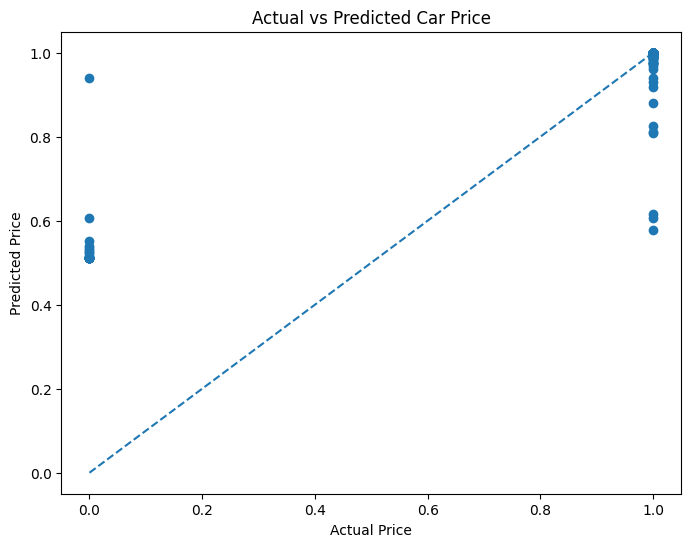

In [39]:
# Actual vs Predicted graph
plt.figure(figsize=(8, 6))

plt.scatter(test_y, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Price")

minimum = min(test_y.min(), y_pred.min())
maximum = max(test_y.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.show()

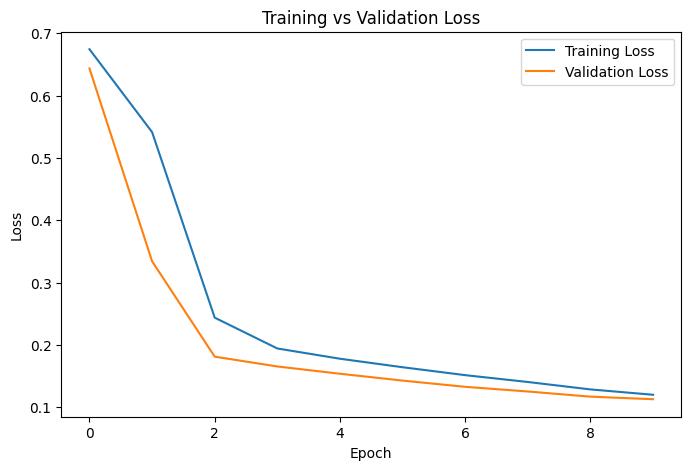

In [40]:
# Training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [41]:
# Save the model
model.save("car_price_model_17_features.keras")

print("Model saved successfully!")

Model saved successfully!


In [42]:
import joblib

# Save scaler
joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [43]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'app.py', 'Car_Price_ANN.ipynb', 'car_price_model_17_features.keras', 'data', 'Diabetes_Data_Analysis_Cleaning_Train_Test.ipynb', 'scaler.pkl']
